# Task 3

### Downloading CLIP

In [1]:
!pip install -q ftfy regex tqdm
!pip install -q git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


### Importing libraries

In [11]:
import torch
import clip
from torchvision import datasets
from torch.utils.data import DataLoader
import torch.nn.functional as functional
from sklearn.metrics import accuracy_score
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

if torch.cuda.is_available() == True:
    device = 'cuda'
else:
    device = 'cpu'

print(f'device: {device}')

from google.colab import drive
drive.mount('/content/drive')


device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Task 3.1

### Loading datasets and model

In [ ]:
clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)

stl_10 = datasets.STL10(root='/content/drive/MyDrive/datasets', split='test', transform=clip_preprocess, download=True)

stl_dataloader = DataLoader(stl_10, batch_size=64, shuffle=False)


100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 121MiB/s]


### Zero shot classification accuracy

In [ ]:
class_list = stl_10.classes

prompted_labels = []
for label in class_list:
    prompted_labels.append(f'a photo of a {label}.')

descriptive_prompt = [
    'a photograph of an airplane flying in the sky',
    'a photograph of a bird which has feathers, a beak, and wings.',
    'a photograph of a car on a road, which has wheels, windscreen, and headlights.',
    'a photograph of a cat with fur, pointed ears, whiskers, a tail, and 4 legs.',
    'a photograph of a deer with fur and four legs.',
    'a photograph of a dog with four legs, ears, and tail',
    'a photograph of a horse with four legs and fur',
    'a photograph of a monkey with two arms, two legs, a tail and fur.',
    'a photograph of a ship which is floating in water.',
    'a photograph of a truck on a road which is bigger than a car.'
]

class_list_tokenized = clip.tokenize(class_list).to(device)
prompted_labels_tokenized = clip.tokenize(prompted_labels).to(device)
descriptive_prompt_tokenized = clip.tokenize(descriptive_prompt).to(device)

class_list_accuracy = 0
prompted_labels_accuracy = 0
descriptive_prompt_accuracy = 0

with torch.no_grad():
    for image, label in stl_dataloader:
        image = image.to(device)
        label = label.to(device)

        image_to_text, text_to_image = clip_model(image, class_list_tokenized)
        class_list_predictions = image_to_text.argmax(dim=1)
        class_list_accuracy += accuracy_score(label.detach().cpu().numpy(), class_list_predictions.detach().cpu().numpy()) * 100

        image_to_text, text_to_image = clip_model(image, prompted_labels_tokenized)
        prompted_labels_predictions = image_to_text.argmax(dim=1)
        prompted_labels_accuracy += accuracy_score(label.detach().cpu().numpy(), prompted_labels_predictions.detach().cpu().numpy()) * 100

        image_to_text, text_to_image = clip_model(image, descriptive_prompt_tokenized)
        descriptive_prompt_predictions = image_to_text.argmax(dim=1)
        descriptive_prompt_accuracy += accuracy_score(label.detach().cpu().numpy(), descriptive_prompt_predictions.detach().cpu().numpy()) * 100

class_list_accuracy = class_list_accuracy / len(stl_dataloader)
prompted_labels_accuracy = prompted_labels_accuracy / len(stl_dataloader)
descriptive_prompt_accuracy = descriptive_prompt_accuracy / len(stl_dataloader)

print(f'plain labels accuracy: {class_list_accuracy}%')
print(f'prompted text accuracy: {prompted_labels_accuracy}%')
print(f'descriptive prompt accuracy: {descriptive_prompt_accuracy}%')




plain labels accuracy: 96.2625%
prompted text accuracy: 97.275%
descriptive prompt accuracy: 94.6%


### Visualizing accuracy

/tmp/ipykernel_560/2446400697.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


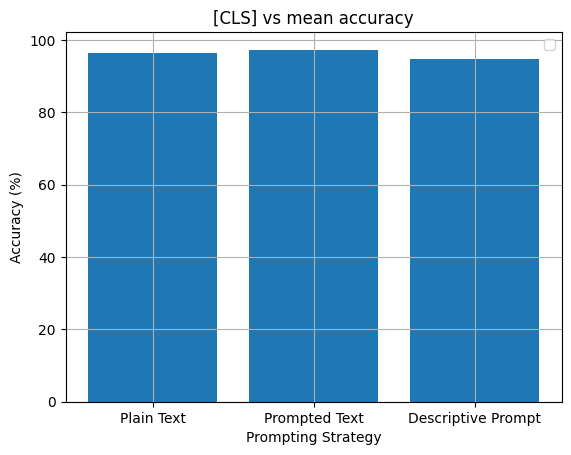

In [ ]:
prompting_strategies = ['Plain Text', 'Prompted Text', 'Descriptive Prompt']
accuracies = [class_list_accuracy, prompted_labels_accuracy, descriptive_prompt_accuracy]

plt.figure()
plt.bar(prompting_strategies, accuracies)

plt.title('[CLS] vs mean accuracy')
plt.xlabel('Prompting Strategy')
plt.ylabel('Accuracy (%)')
plt.grid()
plt.legend()

plt.show()

# Task 3.2

### Loading dataset and model

In [3]:
clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)

stl_10 = datasets.STL10(root='/content/drive/MyDrive/datasets', split='test', transform=clip_preprocess, download=True)

stl_dataloader = DataLoader(stl_10, batch_size=64, shuffle=False)


100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 198MiB/s]


### Collecting coordinates for TSNE (not normalized)

In [9]:
total_batch = 1
curr_batch = 0

stl_classes = stl_10.classes

with torch.no_grad():
  for image, label in stl_dataloader:
      image = image.to(device)
      label = label.to(device)

      if curr_batch == total_batch:
          break

      label_text = []
      for i in range(label.shape[0]):
          label_text.append(stl_classes[label[i].item()])

      tokenized_label = clip.tokenize(label_text).to(device)

      image_embeddings = clip_model.encode_image(image)
      text_embeddings = clip_model.encode_text(tokenized_label)

      curr_batch += 1

tsne = TSNE(random_state=42)

combined_embeddings = torch.cat([image_embeddings, text_embeddings], dim=0)

coordinates = tsne.fit_transform(combined_embeddings.detach().cpu().numpy())


### Visualizing embeddings on scatter plot (not normalized)

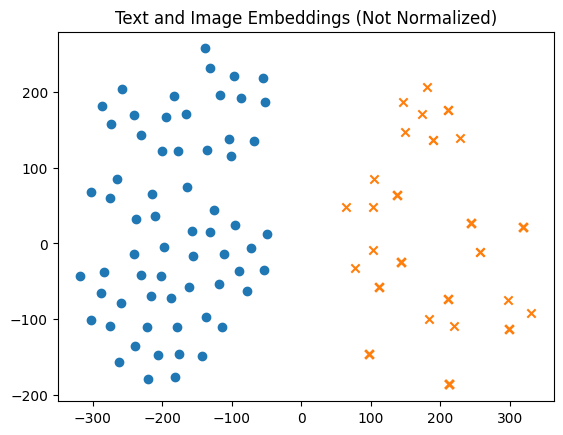

In [10]:
image_coordinates = coordinates[:image_embeddings.shape[0]]
text_coordinates = coordinates[image_embeddings.shape[0]:]

plt.figure()
plt.scatter(image_coordinates[:,0], image_coordinates[:,1], marker='o', label='Image')
plt.scatter(text_coordinates[:,0], text_coordinates[:,1], marker='x', label='Text')
plt.title('Text and Image Embeddings (Not Normalized)')

plt.show()

### Collecting coordinates for TSNE (normalized)

In [12]:
total_batch = 1
curr_batch = 0

stl_classes = stl_10.classes

with torch.no_grad():
  for image, label in stl_dataloader:
      image = image.to(device)
      label = label.to(device)

      if curr_batch == total_batch:
          break

      label_text = []
      for i in range(label.shape[0]):
          label_text.append(stl_classes[label[i].item()])

      tokenized_label = clip.tokenize(label_text).to(device)

      image_embeddings = clip_model.encode_image(image)
      text_embeddings = clip_model.encode_text(tokenized_label)

      curr_batch += 1

tsne = TSNE(random_state=42)

normalized_image_embeddings = functional.normalize(image_embeddings, p=2, dim=1)
normalized_text_embeddings = functional.normalize(text_embeddings, p=2, dim=1)

combined_embeddings = torch.cat([normalized_image_embeddings, normalized_text_embeddings], dim=0)

coordinates = tsne.fit_transform(combined_embeddings.detach().cpu().numpy())


### Visualizing embeddings on scatter plot (normalized)

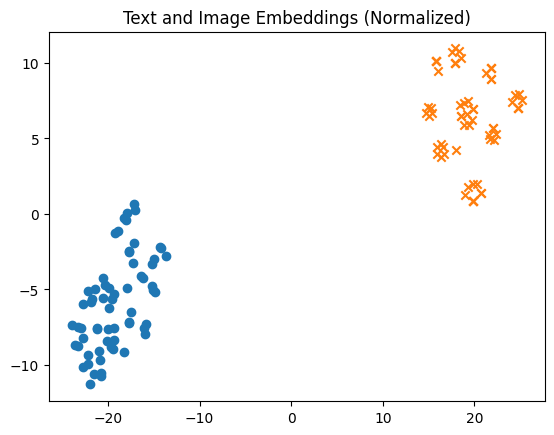

In [14]:
image_coordinates = coordinates[:image_embeddings.shape[0]]
text_coordinates = coordinates[image_embeddings.shape[0]:]

plt.figure()
plt.scatter(image_coordinates[:,0], image_coordinates[:,1], marker='o', label='Image')
plt.scatter(text_coordinates[:,0], text_coordinates[:,1], marker='x', label='Text')
plt.title('Text and Image Embeddings (Normalized)')

plt.show()